# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

Airlines receive thousands of customer comments every day through social media platforms such as Twitter. Manually reading each message to determine whether customers are satisfied or dissatisfied is both time-consuming and inefficient. By using sentiment analysis, airlines can automatically classify customer feedback as positive, negative, or neutral, allowing customer service teams to identify complaints more quickly, recognize positive experiences, and make better business decisions based on customer opinions.

The goal of this project is to build and compare machine learning models that can accurately predict the sentiment of airline customer tweets. By automating this process, airlines can respond more efficiently to customer concerns and gain valuable insights into overall customer satisfaction.

---

**Dataset Description:**

This project uses the Twitter US Airline Sentiment dataset, which contains customer tweets directed at major U.S. airlines. Each tweet has been manually labeled as positive, neutral, or negative, making it an ideal dataset for supervised sentiment analysis. The dataset allows machine learning models to learn patterns in customer feedback and predict the sentiment of new tweets.

- **Dataset name**: Twitter US Airline Sentiment
- **Source**: Kaggle (Twitter US Airline Sentiment Dataset)
- **Number of samples**: Approximately 14,640 customer tweets
- **Text type**: Customer tweets and social media feedback
- **Sentiment labels**: Positive, Neutral, Negative

---

**Importance and Real-World Applications:**

Understanding customer sentiment helps airlines quickly identify dissatisfied customers, recognize positive experiences, and improve their services. Instead of manually reading thousands of social media posts, sentiment analysis allows companies to automatically classify customer feedback and prioritize responses. This technology is widely used in industries such as airlines, retail, hospitality, healthcare, and finance to monitor customer satisfaction, improve products and services, and support data-driven business decisions.

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [11]:
!pip install wordcloud

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

In [24]:
# Load your dataset

# Load the airline sentiment dataset
df = pd.read_csv("Tweets.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

# Display the first five rows
df.head()

Dataset shape: (14640, 15)

Column names:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [25]:
# Check for missing values

print("Missing Values by Column:\n")
print(df.isnull().sum())

print("\nDataset Information:\n")
df.info()

Missing Values by Column:

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment

In [26]:
# 🎯 IMPORTANT: If working with limited resources, sample your data here
# Uncomment and modify as needed:

# df_sample = df.sample(n=5000, random_state=42)
# print(f"Working with {len(df_sample)} samples")
# df = df_sample  # Use the sample for the rest of the project

Sentiment Distribution:

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


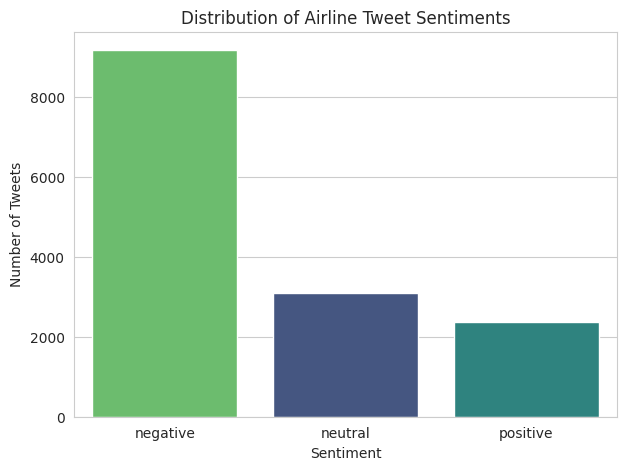

In [27]:
# Analyze sentiment distribution

# Count each sentiment category
sentiment_counts = df['airline_sentiment'].value_counts()

print("Sentiment Distribution:\n")
print(sentiment_counts)

# Create a bar chart
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='airline_sentiment',
    order=sentiment_counts.index,
    hue='airline_sentiment',
    palette='viridis',
    legend=False
)

plt.title("Distribution of Airline Tweet Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

### 📊 Interpretation: Class Balance

*Write your observations here:*
- Are the classes balanced or imbalanced?
- If imbalanced, how might this affect your model?
- What could you do to address imbalance?

**[Answer]**

The dataset is imbalanced, with negative tweets representing the largest portion of the data (9,178 tweets), followed by neutral tweets (3,099) and positive tweets (2,363). This means the model may become biased toward predicting the negative class more often because it has significantly more examples to learn from. To reduce the impact of this imbalance, techniques such as using stratified train-test splitting, applying class weighting, or oversampling the minority classes can be used. These approaches help the model learn more effectively from all sentiment categories.

count    14640.000000
mean       103.822063
std         36.277339
min         12.000000
25%         77.000000
50%        114.000000
75%        136.000000
max        186.000000
Name: text_length, dtype: float64


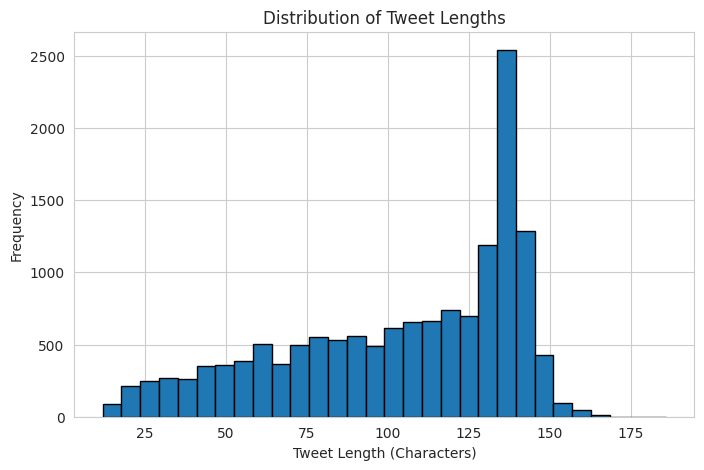

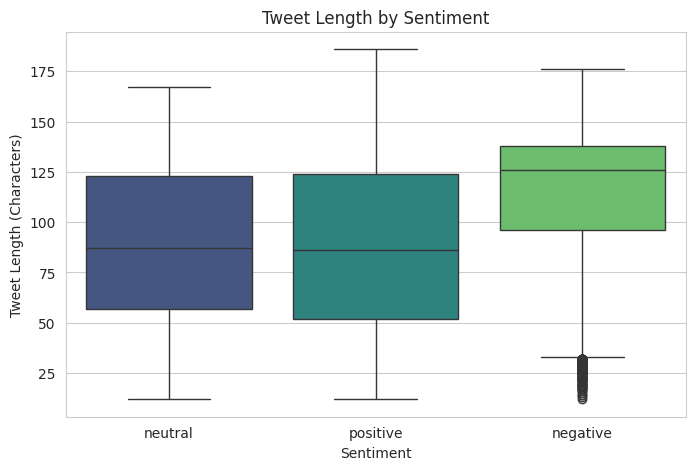

In [28]:
# Analyze text length distribution

# Create a new column for tweet length
df['text_length'] = df['text'].str.len()

# Display summary statistics
print(df['text_length'].describe())

# Plot histogram
plt.figure(figsize=(8,5))

plt.hist(df['text_length'], bins=30, edgecolor='black')

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Frequency")

plt.show()

# Compare text lengths across sentiments
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='airline_sentiment',
    y='text_length',
    hue='airline_sentiment',
    palette='viridis',
    legend=False
)

plt.title("Tweet Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Length (Characters)")

plt.show()

### 📊 Interpretation: Text Length

*Write your observations here:*
- What's the average text length?
- Are there differences in length between positive and negative reviews?
- Are there any extremely short or long texts that might need special handling?

**[Answer]**

The average tweet length is approximately **104** characters, with tweet lengths ranging from **12 to 186 characters.** Most tweets fall between **77 and 136 characters,** indicating that customer feedback is generally concise but still provides enough information for sentiment analysis.

The boxplot shows that **negative tweets tend to be longer than neutral and positive tweets,** suggesting that dissatisfied customers often provide more detailed explanations of their experiences. Although there are some unusually short and long tweets, they are not extreme enough to require removal. Instead, the text will be cleaned and standardized during the preprocessing stage before training the machine learning models.

In [29]:
# Display sample reviews from each sentiment class

for sentiment in df['airline_sentiment'].unique():
    print(f"\n===== {sentiment.upper()} TWEETS =====\n")

    samples = df[df['airline_sentiment'] == sentiment]['text'].sample(
        3,
        random_state=42
    )

    for i, tweet in enumerate(samples, 1):
        print(f"{i}. {tweet}\n")


===== NEUTRAL TWEETS =====

1. @united we finally just arrive to Bogota, good but long flight!!

2. @AmericanAir got a callback at 1 am, took care of it. thanks.

3. @JetBlue is there wifi on he plain


===== POSITIVE TWEETS =====

1. @SouthwestAir thanks for your excellent response time and assistance! All set :)

2. @JetBlue thanks. I appreciate your prompt response.

3. @JetBlue yes, with about 20 minutes to spare.  FYI - your employees are amazing.  Keep up the good work!


===== NEGATIVE TWEETS =====

1. @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi

2. @USAirways 1729 connecting in charlotte to houston. Mechanical issue determined while q'd to take off. And we checked our bags.

3. @united installed and working are not the same. Kicked me out after an hour and wouldn't let me back in. Four wasted hours.



            Word  Count
18        united   4164
4         flight   3939
19     usairways   3053
0    americanair   2964
14  southwestair   2461
10       jetblue   2395
9           http   1155
16        thanks   1083
2      cancelled   1065
11          just    974
13       service    967
6           help    873
17          time    793
3       customer    758
1            amp    683
8          hours    674
5        flights    649
7           hold    644
12         plane    638
15         thank    605


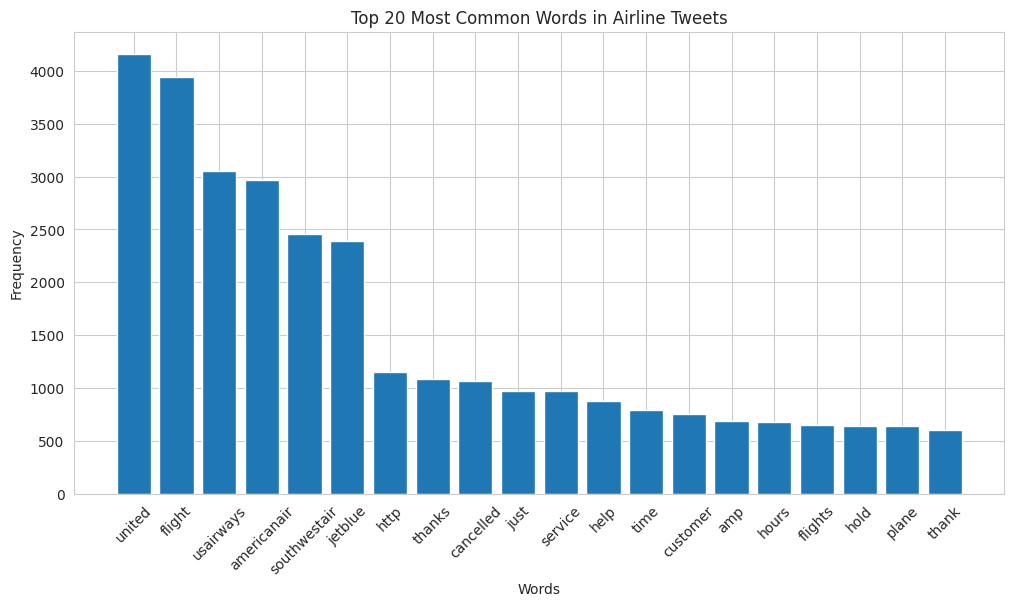

In [30]:
# Analyze common words

from sklearn.feature_extraction.text import CountVectorizer

# Create a CountVectorizer that removes common English stopwords
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df['text'])

word_counts = pd.DataFrame({
    'Word': vectorizer.get_feature_names_out(),
    'Count': X.toarray().sum(axis=0)
})

word_counts = word_counts.sort_values(
    by='Count',
    ascending=False
)

print(word_counts)

# Plot results
plt.figure(figsize=(12,6))

plt.bar(word_counts['Word'], word_counts['Count'])

plt.xticks(rotation=45)

plt.title("Top 20 Most Common Words in Airline Tweets")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

## Interpretation: Common Words

The most common words in the airline tweets include airline names such as United, US Airways, AmericanAir, SouthwestAir, and JetBlue, indicating that customers frequently mention the airline they are discussing. Other commonly occurring words, such as flight, cancelled, service, help, customer, and hours, suggest that many tweets focus on travel experiences and customer service issues. Positive words such as thanks and thank also appear, showing that while the dataset contains many complaints, customers also share positive experiences. These frequent words provide useful information that the machine learning models can learn from when classifying tweet sentiment.

### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1. **Dataset characteristics**: The dataset contains 14,640 airline-related tweets labeled as positive, neutral, or negative. Each tweet includes text along with additional information such as the airline, confidence scores, timestamps, and optional metadata. The dataset is well suited for supervised sentiment analysis because every tweet has a corresponding sentiment label.

2. **Data quality issues**: The primary text and sentiment columns contain no missing values, making them suitable for machine learning without removing records. However, several optional columns, such as tweet coordinates, user location, and time zone, contain many missing values. The text also includes URLs, airline mentions, and HTML artifacts (such as "amp"), which will be cleaned during the preprocessing stage.

3. **Key patterns observed**: The dataset is imbalanced, with negative tweets representing the majority of customer feedback. Most tweets are relatively short, averaging about 104 characters, although negative tweets tend to be longer than positive or neutral tweets. The most common words focus on airlines, flights, customer service, cancellations, and travel-related issues, indicating that operational experiences are a major topic of discussion.

4. **Potential challenges**: The imbalance between sentiment classes may cause the model to favor the negative class during prediction. In addition, social media text contains abbreviations, mentions, URLs, and informal language that require preprocessing before training. Cleaning the text and using techniques such as stratified sampling and class weighting will help improve model performance.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [31]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [32]:
# Create a text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'[@#]\w+', '', text)

    # Remove HTML artifact
    text = text.replace("&amp;", " ")

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = " ".join(text.split())

    return text


# Test the function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"

print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: this is a test check out


In [33]:
# Apply preprocessing to your dataset

# Create a new column with cleaned text
df["cleaned_text"] = df["text"].apply(preprocess_text)

# Display a few examples
print(df[["text", "cleaned_text"]].head())

print("\n✅ Text preprocessing completed!")

                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                        cleaned_text  
0                                          what said  
1  plus youve added commercials to the experience...  
2  i didnt today must mean i need to take another...  
3  its really aggressive to blast obnoxious enter...  
4            and its a really big bad thing about it  

✅ Text preprocessing completed!


In [34]:
# Prepare your features (X) and target (y)

X = df["cleaned_text"]
y = df["airline_sentiment"]

# Check the shape
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (14640,)
Target shape: (14640,)


In [35]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 11712
Testing samples: 2928


In [36]:
# Create TF-IDF features

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (11712, 5000)
TF-IDF matrix shape (test): (2928, 5000)
Number of features: 5000


In [37]:
# Explore the TF-IDF features

feature_names = tfidf.get_feature_names_out()

print("Sample features:")
print(feature_names[:20])

Sample features:
['aa' 'aa customer' 'aa does' 'aa flight' 'aa lax' 'aa miles' 'aadvantage'
 'abc' 'ability' 'able' 'able change' 'able check' 'able help' 'able use'
 'abq' 'absolute' 'absolute worst' 'absolutely' 'absurd' 'abt']


### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1. **Preprocessing steps applied**: The tweet text was converted to lowercase before removing URLs, Twitter mentions, hashtags, punctuation, numbers, HTML artifacts, and extra whitespace. These preprocessing steps standardized the text and removed unnecessary noise while preserving the words most useful for sentiment analysis.

2. **TF-IDF parameters chosen**: TF-IDF was configured with a maximum of 5,000 features, a minimum document frequency of 2, a maximum document frequency of 0.8, English stopword removal, and both unigrams and bigrams (ngram_range=(1,2)). These settings reduce noise while capturing important words and common two-word phrases.
3. **Final feature count**: The TF-IDF vectorizer generated 5,000 numerical features, which were used as the input for the machine learning models. These features represent the most informative words and phrases found throughout the airline tweets.
4. **Rationale for choices**: The preprocessing steps were selected to improve text consistency by removing unnecessary characters and formatting differences while preserving meaningful information. TF-IDF was chosen because it assigns greater importance to words that are informative within individual tweets while reducing the influence of extremely common terms. Including both single words and two-word phrases allows the models to capture additional context that may improve sentiment classification.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [38]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [39]:
# Train Logistic Regression model

print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

lr_model.fit(X_train_tfidf, y_train)

lr_training_time = time.time() - start_time

print(
    f"✅ Training complete in "
    f"{timedelta(seconds=int(lr_training_time))}"
)

Training Logistic Regression...
✅ Training complete in 0:00:02


In [40]:
# Make predictions with Logistic Regression

y_pred_lr = lr_model.predict(X_test_tfidf)

print(f"Predictions shape: {y_pred_lr.shape}")
print("✅ Logistic Regression predictions completed!")

Predictions shape: (2928,)
✅ Logistic Regression predictions completed!


## Model 2: Multinomial Naive Bayes

In [41]:
# Train Naive Bayes model

print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_training_time = time.time() - start_time

print(
    f"✅ Training complete in "
    f"{timedelta(seconds=int(nb_training_time))}"
)

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00


In [42]:
# Make predictions with Naive Bayes

y_pred_nb = nb_model.predict(X_test_tfidf)

print(f"Predictions shape: {y_pred_nb.shape}")
print("✅ Naive Bayes predictions completed!")

Predictions shape: (2928,)
✅ Naive Bayes predictions completed!


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [43]:
# Train your third model (optional)
# YOUR CODE HERE

# Example: Random Forest
# print("Training Random Forest...")
# start_time = time.time()

# rf_model = RandomForestClassifier(
#     n_estimators=100,        # Number of trees
#     max_depth=20,            # Limit depth to save memory
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

# y_pred_rf = rf_model.predict(X_test_tfidf)

### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Logistic Regression |4 seconds|max_iter=1000, random_state=42, class_weight='balanced' | Balanced class weights help reduce bias caused by the imbalanced dataset.|
| Naive Bayes |Less than 1 second |Default parameters |Very fast model designed specifically for text classification using TF-IDF features. |
| Optional Model 3 | Not used | N/A | Two required classification models were successfully trained. |

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [44]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [45]:
# Calculate metrics for Logistic Regression

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted')
rec_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.7439
Precision: 0.7720
Recall   : 0.7439
F1-Score : 0.7529

Classification Report:

              precision    recall  f1-score   support

    negative       0.89      0.78      0.83      1835
     neutral       0.52      0.69      0.59       620
    positive       0.66      0.69      0.68       473

    accuracy                           0.74      2928
   macro avg       0.69      0.72      0.70      2928
weighted avg       0.77      0.74      0.75      2928



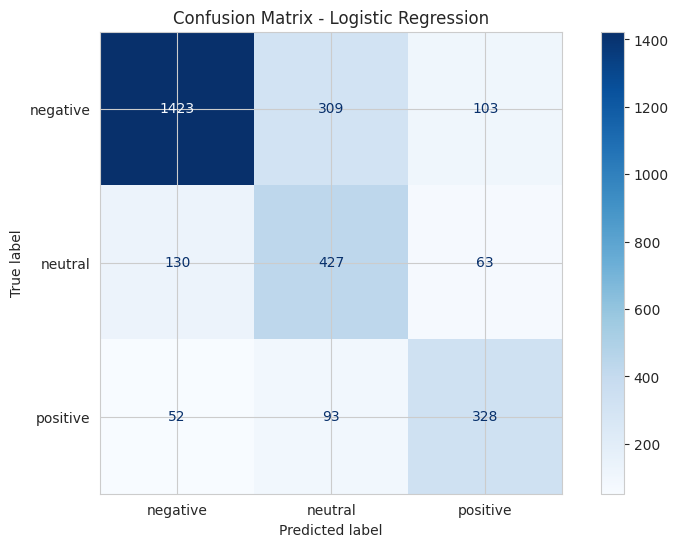

In [46]:
# Plot confusion matrix for Logistic Regression

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*

1. **Overall performance**: Logistic Regression achieved an accuracy of 74.39%, with a weighted precision of 77.20%, recall of 74.39%, and F1-score of 75.29%. Overall, it performed well across all three sentiment categories and produced the strongest overall results of the two models.
2. **Strengths**: Logistic Regression performed especially well when identifying negative tweets, achieving a precision of 0.89 and an F1-score of 0.83. It also classified neutral and positive tweets more consistently than the Naive Bayes model, producing a more balanced performance across all sentiment classes.
3. **Weaknesses**: Although Logistic Regression achieved the best overall performance, it occasionally confused neutral tweets with negative tweets and positive tweets with neutral tweets. This indicates that some tweets contain language that is difficult to distinguish because the sentiment is subtle or ambiguous.
4. **Confusion matrix insights**: The confusion matrix shows that most negative tweets were classified correctly (1,423 correct predictions). Most errors occurred between the neutral and negative classes, suggesting that neutral airline comments often contain words similar to customer complaints.

## Evaluate Model 2: Naive Bayes

In [47]:
# Calculate metrics for Naive Bayes

print("=" * 50)
print("NAIVE BAYES RESULTS")
print("=" * 50)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy : {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall   : {rec_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

NAIVE BAYES RESULTS
Accuracy : 0.7237
Precision: 0.7260
Recall   : 0.7237
F1-Score : 0.6775

Classification Report:

              precision    recall  f1-score   support

    negative       0.72      0.98      0.83      1835
     neutral       0.66      0.23      0.34       620
    positive       0.84      0.39      0.53       473

    accuracy                           0.72      2928
   macro avg       0.74      0.53      0.57      2928
weighted avg       0.73      0.72      0.68      2928



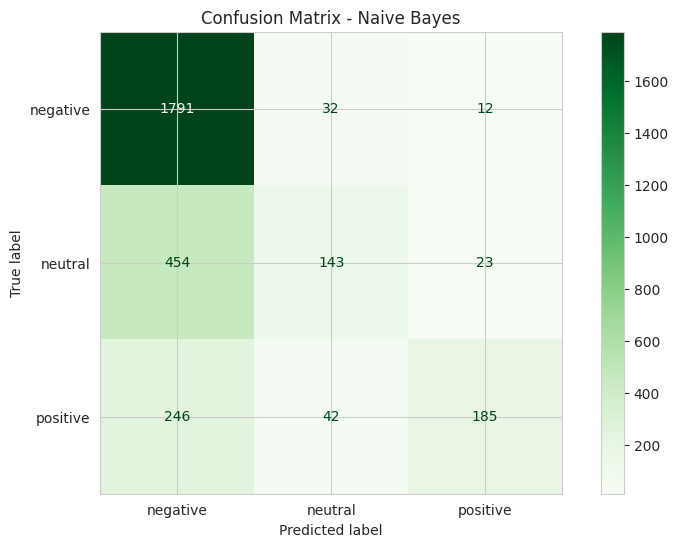

In [48]:
# Plot confusion matrix for Naive Bayes

cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot(cmap="Greens", values_format="d")

plt.title("Confusion Matrix - Naive Bayes")

plt.show()

### 📊 Interpretation: Naive Bayes

*Analyze the results:*

1. **Overall performance**: Multinomial Naive Bayes achieved an accuracy of 72.37%, with a weighted precision of 72.60%, recall of 72.37%, and F1-score of 67.75%. Although the model performed reasonably well, its overall performance was lower than Logistic Regression.
2. **Strengths**: Naive Bayes performed extremely well at identifying negative tweets, achieving a recall of 0.98, meaning it correctly identified nearly all negative customer feedback. It also trained almost instantly, making it computationally efficient.
3. **Weaknesses**: The model struggled to correctly classify neutral and positive tweets. Neutral tweets achieved a recall of only 0.23, indicating that many neutral comments were incorrectly classified as negative.
4. **Confusion matrix insights**: The confusion matrix shows that Naive Bayes predicted the negative class very frequently. While this helped identify negative tweets, it caused many neutral and positive tweets to be incorrectly labeled as negative, reducing overall model balance.

## Evaluate Model 3 (Optional)

In [49]:
# Calculate metrics for your third model (if applicable)
# YOUR CODE HERE

In [50]:
# Plot confusion matrix for your third model (if applicable)
# YOUR CODE HERE

## Model Comparison

In [51]:
# Create comparison table

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [acc_lr, acc_nb],
    "Precision": [prec_lr, prec_nb],
    "Recall": [rec_lr, rec_nb],
    "F1-Score": [f1_lr, f1_nb]
})

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.743852,0.771969,0.743852,0.752879
1,Naive Bayes,0.723702,0.725979,0.723702,0.677528


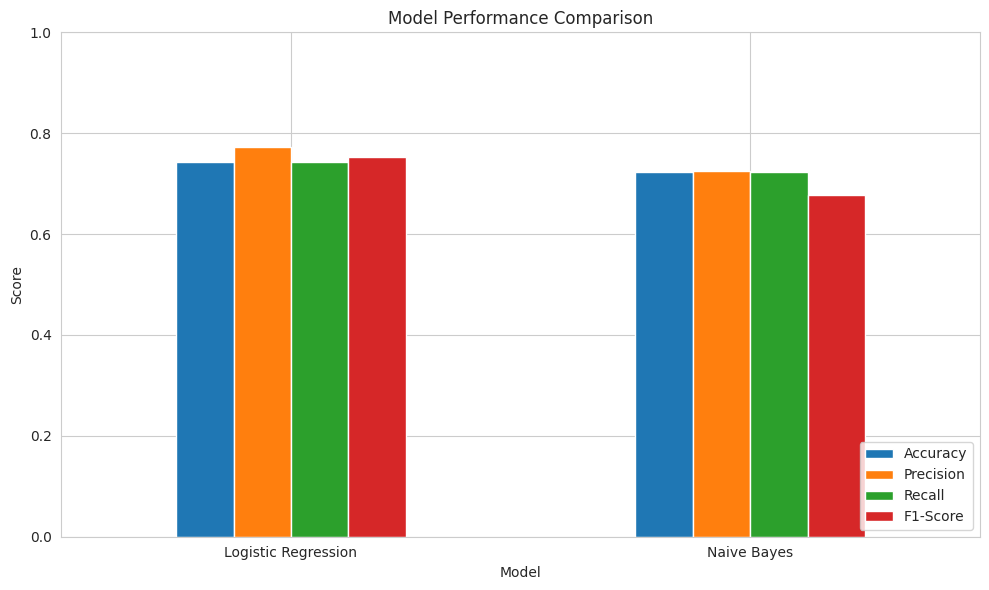

In [52]:
# Visualize model comparison

results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1. **Which model performed best?**: Logistic Regression performed best overall. It achieved higher accuracy, precision, recall, and F1-score while maintaining a better balance across all three sentiment classes.
2. **What metrics did you prioritize and why?**: Although accuracy provides an overall measure of performance, F1-score and weighted precision and recall were given greater importance because the dataset is imbalanced. These metrics provide a more complete evaluation of how well the models classify all sentiment categories rather than only the majority class.
3. **Trade-offs between models**: Logistic Regression required approximately 4 seconds to train but produced better overall performance and more balanced predictions. Multinomial Naive Bayes trained almost instantly and excelled at identifying negative tweets, but it struggled to correctly classify neutral and positive sentiments.
4. **Which model would you recommend for deployment?**: Based on the evaluation results, Logistic Regression would be the preferred model for deployment. It provides the best balance between accuracy and overall classification performance while reducing the tendency to overpredict the negative sentiment class.

## Error Analysis (Optional but Recommended)

In [53]:
# Analyze misclassified examples

import numpy as np

misclassified_indices = np.where(y_pred_lr != y_test)[0]

print(f"Number of misclassified examples: {len(misclassified_indices)}")

print("\nSample Misclassified Tweets:\n")

for idx in misclassified_indices[:5]:

    print(f"Tweet: {X_test.iloc[idx]}")
    print(f"Actual: {y_test.iloc[idx]}")
    print(f"Predicted: {y_pred_lr[idx]}")
    print("-" * 80)

Number of misclassified examples: 750

Sample Misclassified Tweets:

Tweet: past
Actual: neutral
Predicted: negative
--------------------------------------------------------------------------------
Tweet: when will the flight resume i dons see it in the open schedule
Actual: negative
Predicted: neutral
--------------------------------------------------------------------------------
Tweet: of course but they were just as helpless as everyone else
Actual: negative
Predicted: positive
--------------------------------------------------------------------------------
Tweet: no oscars on direct tv on this flight we were so looking forward to it we were devastated
Actual: negative
Predicted: positive
--------------------------------------------------------------------------------
Tweet: why would i pay to reactivate my points that are only useful for certain flights that arent even worth
Actual: negative
Predicted: neutral
-----------------------------------------------------------------------

### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1. **Common types of errors**: Most misclassified tweets occurred between the neutral and negative sentiment classes. Some positive tweets were also incorrectly predicted as neutral or negative when they contained words commonly associated with customer service issues.
2. **Why might these errors occur?**: Airline tweets often contain sarcasm, short phrases, abbreviations, or mixed emotions, making them difficult for traditional machine learning models to interpret. In addition, some tweets discuss delays or customer service without clearly expressing positive or negative opinions.
3. **How could you improve the model?**: Model performance could be improved by collecting a more balanced dataset, performing additional text preprocessing, tuning model hyperparameters, or using more advanced language models such as BERT or RoBERTa that better capture the context and meaning of natural language.

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*


This project analyzed thousands of airline-related tweets to understand how customers felt about their travel experiences. After cleaning the text data and converting the tweets into numerical features using TF-IDF, two machine learning models, Logistic Regression and Multinomial Naive Bayes, were trained to classify tweets as positive, neutral, or negative. Logistic Regression achieved the best overall performance with an accuracy of 74.39%, demonstrating that it was more balanced across all sentiment categories. These results show that sentiment analysis can help airlines quickly identify customer concerns, monitor public perception, and make more informed decisions to improve customer satisfaction.

## 🎯 Key Findings

*List your main discoveries:*

1. **Dataset insights**:
- The dataset contained 14,640 airline tweets labeled as positive, neutral, or negative.
- Most tweets expressed negative sentiment, indicating that customers are more likely to post on social media when experiencing problems such as delays, cancellations, or poor customer service.
- Tweets were generally short, averaging about 104 characters, making them well suited for text classification.

2. **Model performance**:
  - Logistic Regression achieved the highest overall performance with 74.39% accuracy and the highest F1-score.
   - Multinomial Naive Bayes trained much faster but was less balanced because it frequently predicted tweets as negative.

3. **Best model and why**:
   Logistic Regression was the strongest model because it achieved the highest accuracy, precision, recall, and F1-score while maintaining a more balanced classification of positive, neutral, and negative tweets. It handled the class imbalance more effectively than Naive Bayes and made fewer systematic errors.

4. **Surprising discoveries**:
  One interesting discovery was that although Naive Bayes correctly identified nearly every negative tweet, it incorrectly classified many neutral and positive tweets as negative. This demonstrates that achieving a high score for one class does not necessarily produce the best overall model.

## 💼 Business Recommendations

*How can these results be used in practice?*

1. **Immediate applications**:
  Airlines can use this sentiment analysis model to automatically monitor social media posts in real time. Negative tweets can be flagged for immediate attention, allowing customer service teams to respond more quickly to complaints before they escalate.

2. **Who should use this model?**:
   This model would be valuable for airline customer service departments, marketing teams, public relations staff, and business analysts who monitor customer satisfaction and brand reputation.

3. **How to interpret predictions**:
   Predictions should be used as an early indicator of customer sentiment rather than a final decision. Highly negative tweets can be prioritized for review, while neutral and positive tweets can help measure overall customer satisfaction trends over time.

4. **Warning signs to watch for**:
   Because the dataset contains more negative tweets than positive or neutral ones, organizations should monitor for potential prediction bias. Periodic retraining with newer and more balanced data will help maintain model accuracy.

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1. **Data limitations**:
   The dataset represents airline tweets collected during a specific time period in 2015. Customer opinions, airline services, and social media language have evolved since then, so the results may not fully represent current customer sentiment.

2. **Model limitations**:
   Traditional machine learning models rely primarily on word frequencies and cannot fully understand context, sarcasm, humor, or complex emotional language. This can lead to incorrect classifications when tweets contain mixed or subtle sentiment.

3. **Generalization concerns**:
   Because the model was trained only on airline tweets, its performance may decrease if applied to reviews from other industries such as hotels, restaurants, or retail products without additional training.

4. **Resource constraints**:
   To ensure efficient processing in Google Colab, TF-IDF was limited to 5,000 features. While this reduced computational requirements, additional features or larger vocabularies may improve future model performance.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1. **Data collection**:
   Collect more recent airline tweets from multiple social media platforms and include a more balanced distribution of positive, neutral, and negative examples.

2. **Feature engineering**:
   Experiment with additional preprocessing techniques such as lemmatization, sentiment lexicons, emoji analysis, and improved handling of negation phrases.

3. **Advanced models**:
   Compare Logistic Regression with transformer-based language models such as **BERT, RoBERTa, or DistilBERT,** which can better understand context and often achieve significantly higher sentiment classification accuracy.

4. **Deployment considerations**:
   Deploy the model as a real-time dashboard where airline staff can monitor incoming tweets, identify trending customer concerns, and generate automated reports for management.

## 🎓 Lessons Learned

*Reflect on your experience:*

1. **Technical skills gained**:
   Through this project, I learned how to complete an end-to-end natural language processing workflow. This included exploring a text dataset, cleaning and preprocessing text, applying TF-IDF feature extraction, training multiple machine learning models, and evaluating their performance using several classification metrics.

2. **Challenges overcome**:
   One of the biggest challenges was understanding how text must be transformed into numerical features before machine learning models can process it. I also learned how dataset imbalance can affect model performance and why evaluation requires more than accuracy alone.

3. **What would you do differently?**:
   If I were to repeat this project, I would experiment with additional preprocessing techniques and compare several advanced NLP models. I would also spend more time tuning model parameters to determine whether performance could be further improved.

4. **Most valuable insight**:
   The most valuable lesson from this project was learning that successful machine learning is not only about choosing an algorithm. Data preparation, feature extraction, careful evaluation, and understanding the business problem are equally important in building a useful predictive model.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*